### EXPLANATORY DATA ANALYSIS

In [13]:
#Import necessary libraries
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product


In [14]:
# Data Loading
Data_dir_path = os.path.join(os.path.dirname(os.getcwd()), "data", "raw")
file_path = os.path.join(Data_dir_path, "ANN data_316.xlsx")
print(file_path)
# Read  as a dataframe
df = pd.read_excel(file_path)
df.head(10)

/home/mlops-localhost/PycharmProjects/aisi304-flow-stress-optimizer/data/raw/ANN data_316.xlsx


,1/T,Strain,ε͘΄,σ/σmax
0,0.000853,0.05,0.100000,0.453890
1,0.000853,0.05,0.467632,0.517333
2,0.000853,0.05,0.835263,0.594092
3,0.000853,0.05,0.900000,0.600576
4,0.000818,0.05,0.100000,0.400384
5,0.000818,0.05,0.467632,0.472501
6,0.000818,0.05,0.835263,0.534318
7,0.000818,0.05,0.900000,0.559611
8,0.000786,0.05,0.100000,0.339231
9,0.000786,0.05,0.467632,0.415931


In [15]:
df.shape

(192, 4)

- The original data has 84 rows of data and 5 columns of data

In [16]:
df.dtypes

1/T       float64
Strain    float64
ε͘΄       float64
σ/σmax    float64
dtype: object

- All the data types are numbers (float)

In [17]:
# Check for null values
df.isnull().sum()

1/T       0
Strain    0
ε͘΄       0
σ/σmax    0
dtype: int64

- There are no null values in the dataset

In [18]:
# Check for duplicates
duplicates = df[df.duplicated()]
print(duplicates.sum())

1/T       0.0
Strain    0.0
ε͘΄       0.0
σ/σmax    0.0
dtype: float64


- There are no duplicate values in the dataset

In [19]:
# Get the dataset description
df.describe()

,1/T,Strain,ε͘΄,σ/σmax
count,192.000000,192.000000,192.000000,192.000000
mean,0.000803,0.325000,0.575724,0.658172
std,0.000036,0.173054,0.321194,0.174746
min,0.000756,0.050000,0.100000,0.270714
25%,0.000778,0.187500,0.375724,0.527098
50%,0.000802,0.325000,0.651447,0.658912
75%,0.000826,0.462500,0.851447,0.781386
max,0.000853,0.600000,0.900000,1.000000


- The dataset has 192 rows and 4 columns.
- The mean, standard deviation, minimum, and maximum values for each column are provided in the description.
- The '1/T' column has a mean of approximately 0.000803.
- The 'Strain' column has a mean of approximately 0.325, and the 'Flow stress' column has a mean of approximately 200 MPa.

In [20]:
# Check for unique values per column.
for column in df.columns:
    unique_values = df[column].nunique()
    print(f"Unique values in column '{column}: {unique_values}")

Unique values in column '1/T: 4
Unique values in column 'Strain: 12
Unique values in column 'ε͘΄: 4
Unique values in column 'σ/σmax: 192


In [21]:
#Check whether the data is a 4 by 4 complete grid
# Step 1: Calculate the expected rows and column for a 4 by 4 grid
expected_rows = df['1/T'].nunique() * df['Strain'].nunique()

print(f"Expected rows: {expected_rows}")
print(f"Actual rows: {len(df)}")
# Step 2: Check for missing combinations
from itertools import product

all_combinations = list(product(
    df['1/T'].unique(),
    df['Strain'].unique()
))

actual_combinations = set(zip(
    df['1/T'],
    df['Strain']
))

missing = [
    comb for comb in all_combinations
    if comb not in actual_combinations
]

print(f"Missing combinations: {len(missing)}")

if missing:
    print("\nMissing rows:")
    for row in missing:
        print(row)

Expected rows: 48
Actual rows: 192
Missing combinations: 0


- Our dataset has 84 rows, which is more than the expected 64 rows for a complete 4 by 4 grid. This indicates that there are duplicate combinations of '1/T', 'ln strain rate', and 'Strain' in the dataset. Additionally, there are no missing combinations, meaning all possible combinations of the three variables are present in the dataset.

## VISUALIZATION OF DATA PATTERNS

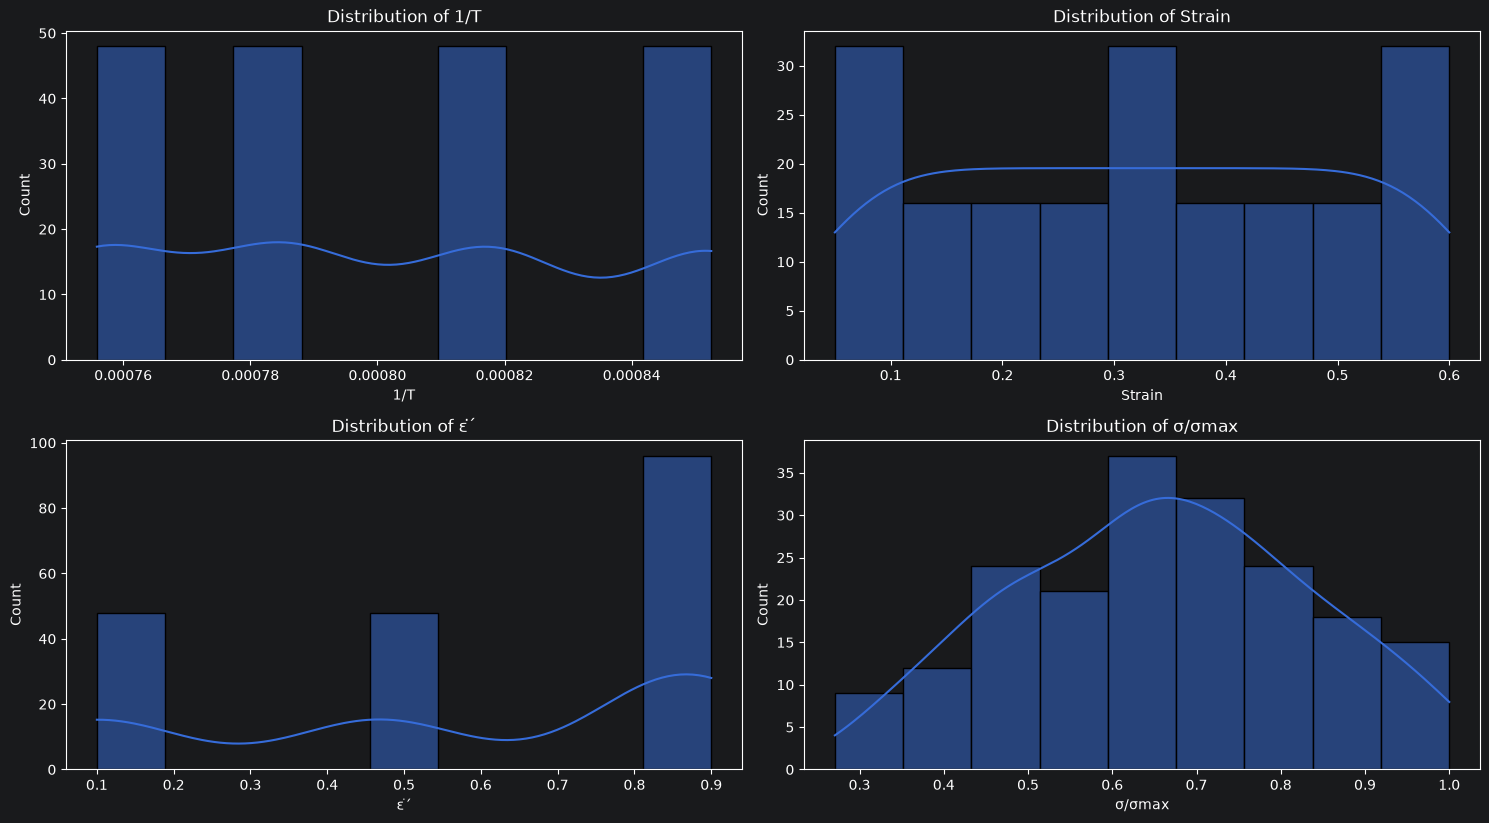

In [22]:
# Distribution plots - to understand the distribution of each variable
plt.figure(figsize=(15,12))
for i, column in enumerate(df.columns):
    plt.subplot(3,2, i + 1)
    sns.histplot(df[column], kde = True)
    plt.title(f'Distribution of {column}')
plt.tight_layout()
plt.show()

### DISTRIBUTION PLOTS
1. 1/T (Temperature): Three discrete bars of roughly equal height (~27 each). This confirms 3 distinct temperature levels, evenly represented. Clean, no imbalance.

2. ln strain rate: Four discrete bars but unequally represented, the highest strain rate (≈2.3) has ~40 counts while the lowest (≈-2.3) has ~20. This means higher strain rates were tested at more strain levels, or appear more in the dataset. Worth keeping in mind during training that the model will see more of one strain rate than others.

3. Strain: The most uniform of all inputs. Every strain level from 0.1 to 0.7 appears with roughly equal frequency (~12 each). This is ideal, no strain value dominates training.

4. σ/σmax (Target): It's right-skewed, concentrated between 0.5 and 0.9, with very few values near 0.2 or 1.0. This means that the model will have less exposure to extreme flow stress values, both very low and near-maximum. That's a known risk area for prediction accuracy, the model will also benefit more from log transforming the target to reduce skewness and improve performance.

5. ε' (raw strain rate): Mirror of ln strain rate as expected, three clusters at 0.1, 0.47, and 0.9. Confirms it carries no new information beyond what ln strain rate already captures. Drop it as an input feature.

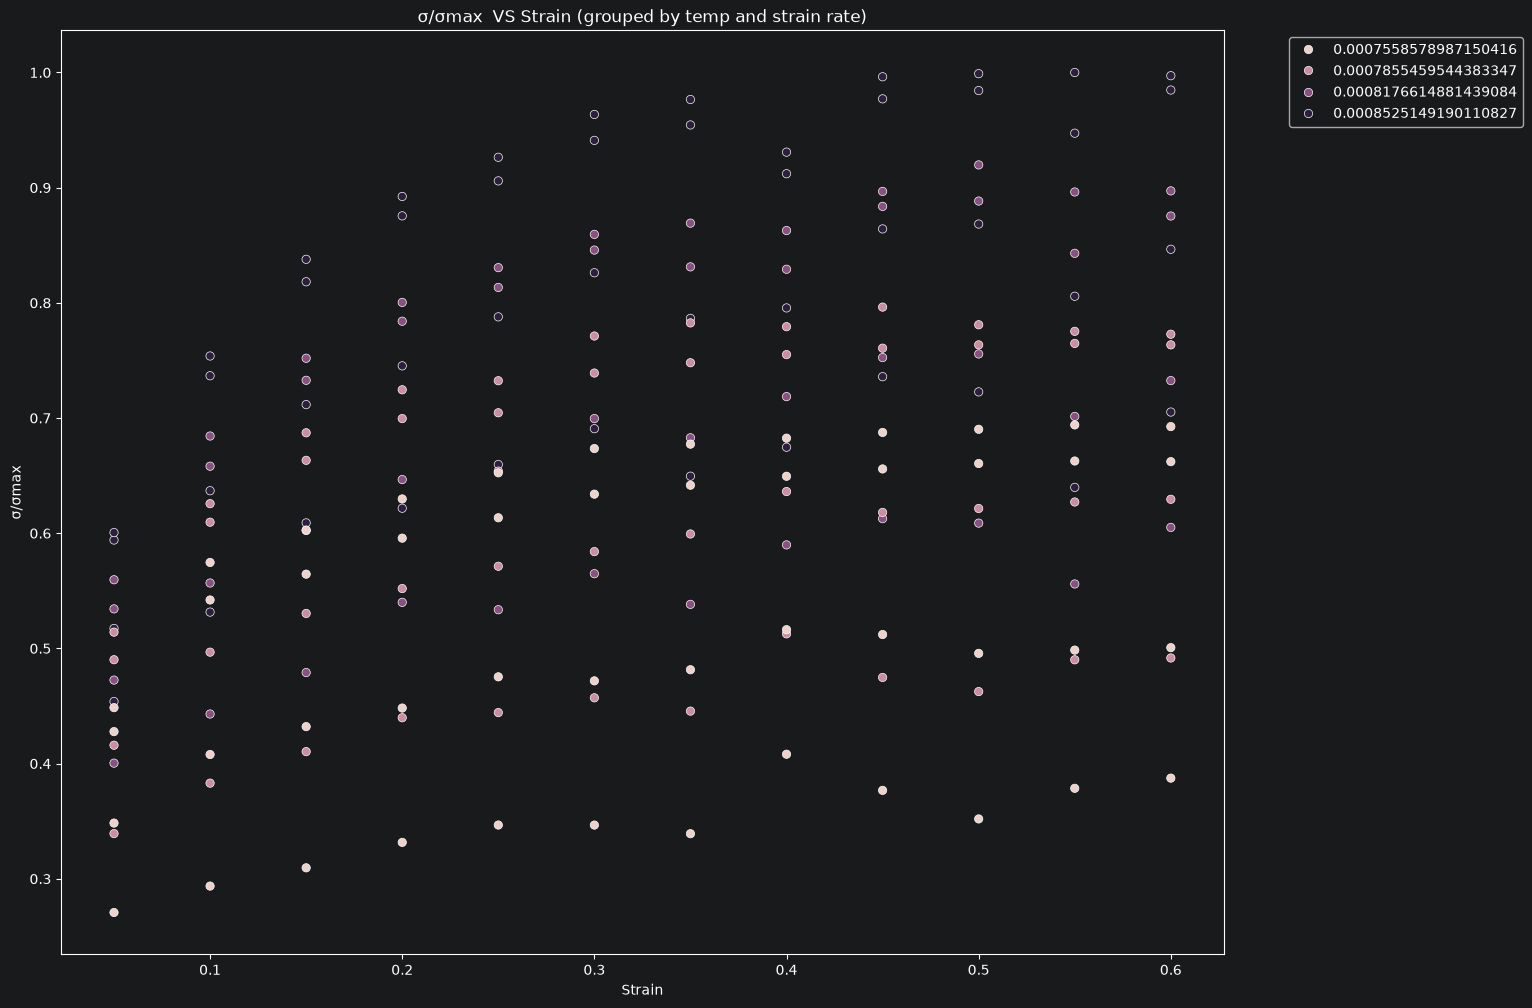

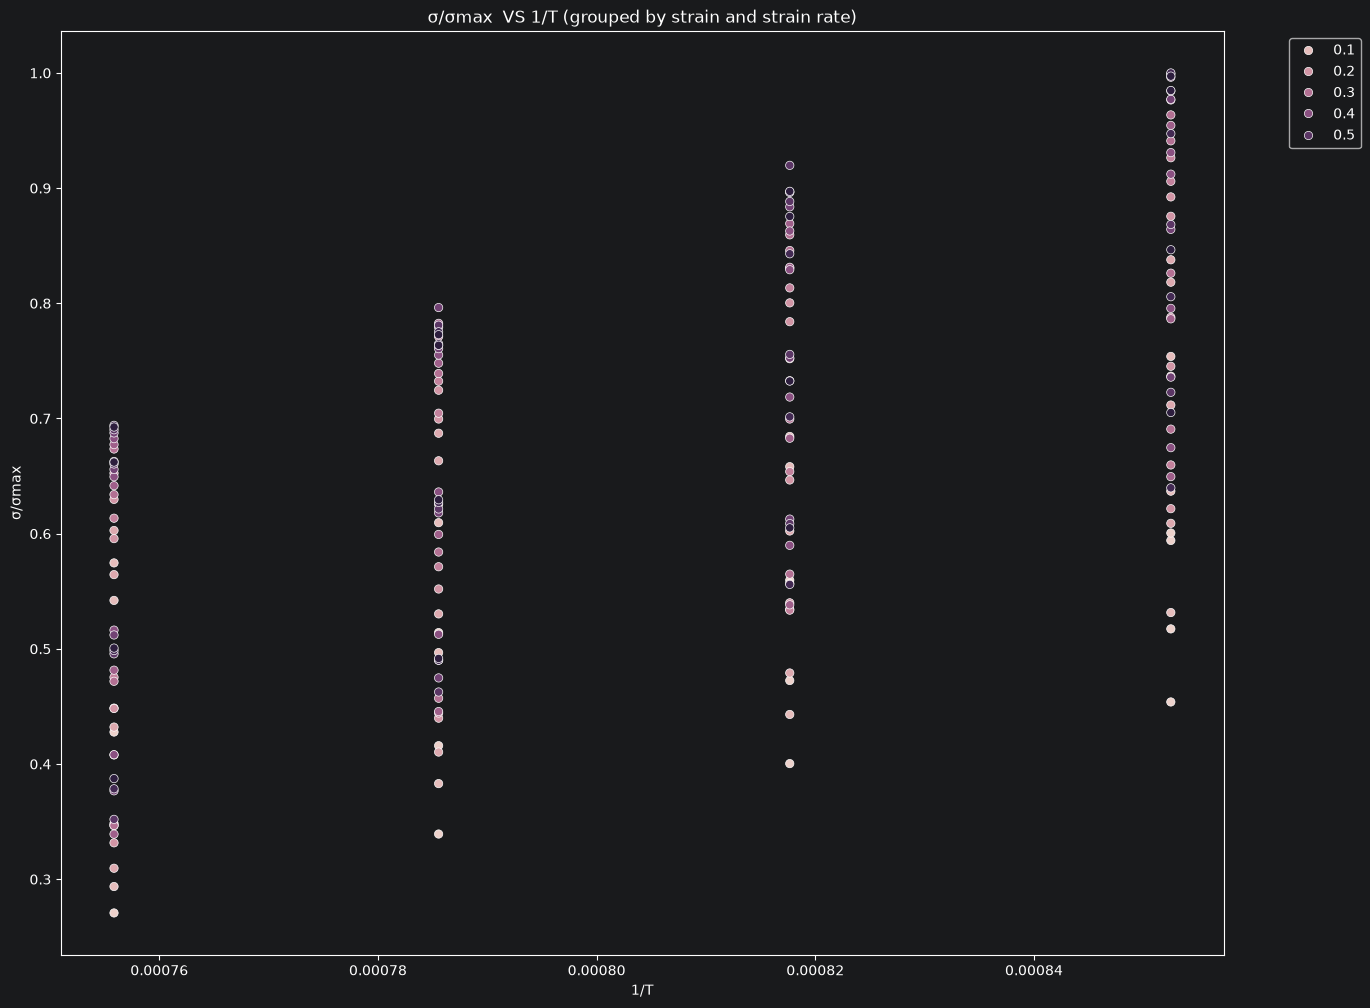

In [23]:
# Relationship plots - to understand the relationships between variables
# Step 1: σ/σmax  VS Strain ( grouped by temp and strain rate)
plt.figure(figsize=(15,12))
sns.scatterplot(data=df, x='Strain', y = 'σ/σmax', hue = '1/T')
plt.title('σ/σmax  VS Strain (grouped by temp and strain rate)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

# Step 2: σ/σmax vs 1/T (grouped by strain and strain rate)
plt.figure(figsize=(15,12))
sns.scatterplot(data = df, x='1/T', y = 'σ/σmax', hue = 'Strain')
plt.title('σ/σmax  VS 1/T (grouped by strain and strain rate)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()



## Exploratory Plot Notes

### Plot 1: Normalized Flow Stress (σ/σmax) vs Strain

This plot shows the clearest relationship in the dataset. As strain increases from **0.1 to 0.7**, the normalized flow stress (**σ/σmax**) increases consistently across all temperature and strain rate conditions. There is no clear peak or drop in stress, only a steady rise.

This suggests that **strain is a strong monotonic predictor** of flow stress, which is a useful sign for the ANN because the model should be able to learn this pattern reliably.

Another important observation is the **large vertical spread** at each strain value. At the same strain level, flow stress still varies significantly depending on **temperature** and **strain rate**. This confirms that all three input variables contribute meaningfully to the material response.

---

### Plot 2: Normalized Flow Stress (σ/σmax) vs Inverse Temperature (1/T)

The data forms **three clear clusters** along the x-axis, reflecting the **three temperature levels** used in the experimental grid.

A clear physical trend is visible. As **1/T increases** (which means **temperature decreases**), the normalized flow stress tends to increase. In other words, **higher temperature leads to lower flow stress**, which is consistent with hot deformation behavior since the material deforms more easily at elevated temperatures.

However, the spread within each temperature cluster is still quite large. This variation is mainly caused by differences in **strain** and **strain rate**, showing that **temperature alone does not fully explain the flow stress response**.

---

### Plot 3: Normalized Flow Stress (σ/σmax) vs ln(Strain Rate)

This plot shows **four discrete ln(strain rate) values**: **-2.3, 0, 2.3, and 2.708**, which matches the strain rate levels in the dataset.

The overall trend is physically meaningful. As **strain rate increases**, the normalized flow stress also increases. This is expected in hot deformation, where faster deformation generally requires higher stress.

One important feature to note is the **large gap between -2.3 and 0** on the x-axis, where no intermediate strain rate values exist. This means there is a relatively sparse region in the dataset, and it is likely where **interpolation will play a critical role** when the ANN makes predictions between measured strain rate conditions.

### DATA CORRELATION

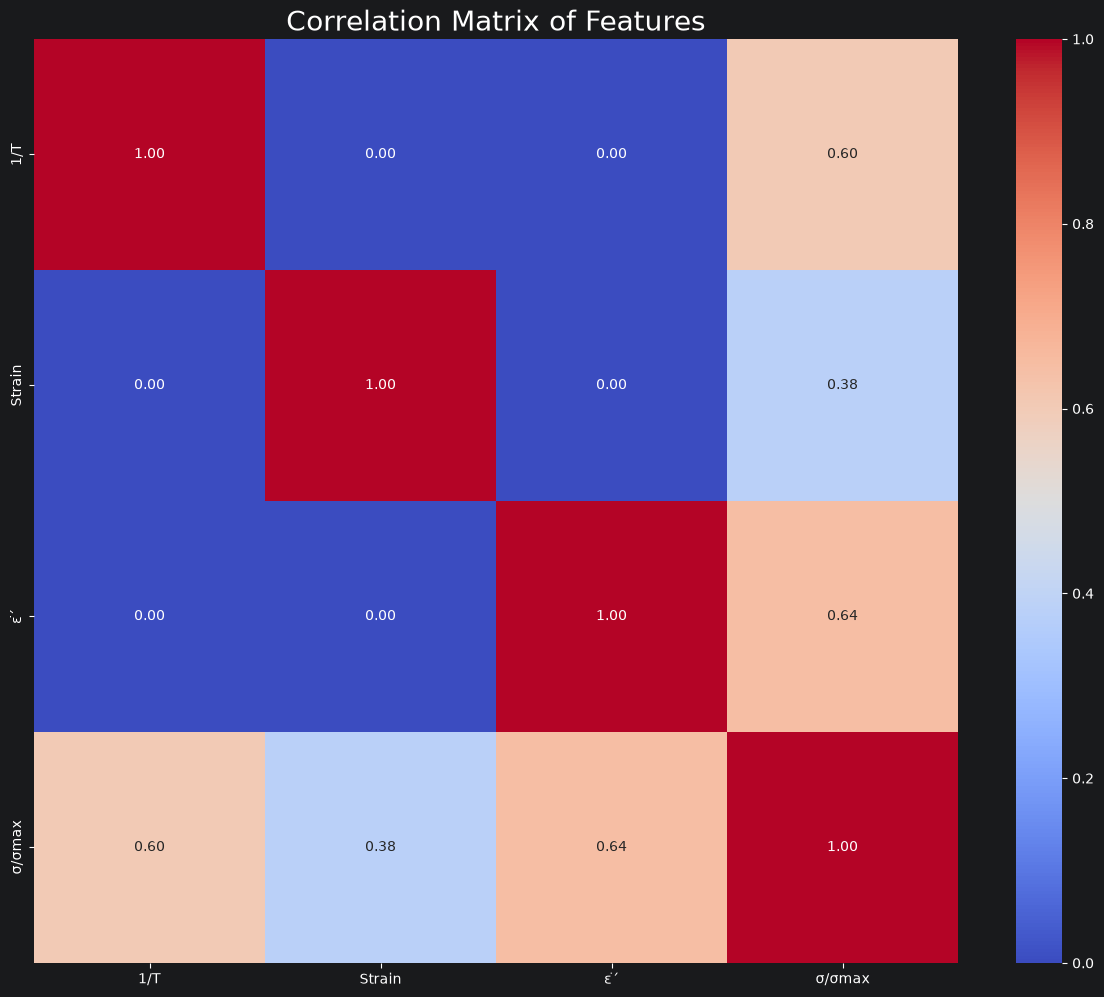

In [24]:
# Create a correlation heatmap
plt.figure(figsize=(15,12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt ='.2f', cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Features", fontsize=20)
plt.show()

## Correlation Heatmap Interpretation

This is the most definitive plot in the exploratory analysis because it summarizes the relationships between all variables in a single view.

### σ/σmax vs ε' = 0.64

This is the **strongest relationship** in the correlation matrix, aside from the trivial diagonal.

It shows that **ε' is the most influential predictor** of normalized flow stress among the three input variables. The ANN is therefore expected to rely strongly on this feature when learning the material response.

---

### 1/T vs σ/σmax = 0.60

This indicates a **moderate-to-strong positive correlation** between inverse temperature and normalized flow stress.

Temperature clearly affects the deformation behavior, and its linear association with stress is close to that of ε', though part of the relationship is likely **nonlinear** in ways a single correlation coefficient can't fully capture. The ANN should still be able to learn these more complex temperature effects beyond what this value reflects on its own.

---

### Strain vs σ/σmax = 0.38

This is the **weakest linear correlation** among the three main inputs.

At first, this may seem unexpected because the earlier strain plot showed a clear increasing trend. However, the lower correlation is mainly due to the wide variation in stress caused by **temperature** and **strain rate** at the same strain values. This reduces the overall linear correlation coefficient.

Even so, strain remains an important predictor and should not be dismissed simply because its pairwise correlation is lower.

---

### Input-to-Input Correlations

The correlations between the three main input variables are all approximately zero:

- **1/T vs Strain = 0.00**
- **1/T vs ε' = 0.00**
- **Strain vs ε' = 0.00**

This means the three input features are essentially **independent of one another**.

From a modeling perspective, this is highly favorable because it means there is **no meaningful multicollinearity** among the retained predictors. Each input contributes a distinct signal, which gives the ANN a cleaner feature space to learn from.

---

### Summary

Ranked by linear association with the target (σ/σmax): **ε' (0.64) > 1/T (0.60) > Strain (0.38)**. None of the three inputs are redundant with one another (all pairwise input correlations ≈ 0.00), so all three are worth retaining as ANN inputs.